In [1]:
# Test script 3

In [1]:
import xarray as xr
import numpy as np
import pandas as pd

In [2]:
# === Path config ===
O3_DIR = "/glade/work/awells/air_quality/O3_obs/"
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"

In [3]:
# Open observations to use latitude and longitude values
o3 = xr.open_dataset(f"{O3_DIR}Delang_BME_OSDMA8_1990_2017.nc")["ozone"]

In [4]:
pop = xr.open_dataset(f"{POP_DIR}ssp2_total_2010.nc4")["Band1"]

In [6]:
# Step 1: Compute bin edges for o3 grid
def get_grid_edges(centers):
    spacing = np.diff(centers).mean()
    half_spacing = spacing / 2
    edges = np.concatenate([[centers[0] - half_spacing], centers + half_spacing])
    return edges


lat_edges = get_grid_edges(o3['latitude'].values)
lon_edges = get_grid_edges(o3['longitude'].values)

In [8]:
lon_edges

array([-180. , -179.9, -179.8, ...,  179.8,  179.9,  180. ])

In [9]:
# Step 2: Add latitude and longitude as coordinates to pop (if not already)
pop = pop.assign_coords(lat=pop['lat'], lon=pop['lon'])

# Step 3: Bin latitudes
pop_binned_lat = pop.groupby_bins('lat', lat_edges)
# This returns a groupby object over lat_bins — now bin longitudes inside each group manually

# Step 4: Flatten to DataFrame to group on both lat and lon bins
pop_df = pop.to_dataframe(name='pop').reset_index()

In [12]:
pop_df

,lat,lon,pop
0,-55.770833,-179.995833,NaN
1,-55.770833,-179.987500,NaN
2,-55.770833,-179.979167,NaN
3,-55.770833,-179.970833,NaN
4,-55.770833,-179.962500,NaN
...,...,...,...
722735995,83.637500,179.962500,NaN
722735996,83.637500,179.970833,NaN
722735997,83.637500,179.979167,NaN
722735998,83.637500,179.987500,NaN


In [13]:
# Step 5: Assign bin labels
pop_df['lat_bin'] = pd.cut(pop_df['lat'], bins=lat_edges, labels=o3['latitude'].values)
pop_df['lon_bin'] = pd.cut(pop_df['lon'], bins=lon_edges, labels=o3['longitude'].values)

In [14]:
pop_df

,lat,lon,pop,lat_bin,lon_bin
0,-55.770833,-179.995833,NaN,-55.75,-179.95
1,-55.770833,-179.987500,NaN,-55.75,-179.95
2,-55.770833,-179.979167,NaN,-55.75,-179.95
3,-55.770833,-179.970833,NaN,-55.75,-179.95
4,-55.770833,-179.962500,NaN,-55.75,-179.95
...,...,...,...,...,...
722735995,83.637500,179.962500,NaN,NaN,179.95
722735996,83.637500,179.970833,NaN,NaN,179.95
722735997,83.637500,179.979167,NaN,NaN,179.95
722735998,83.637500,179.987500,NaN,NaN,179.95


In [15]:
# Drop rows with NaNs in bins (outside edge cases)
pop_df = pop_df.dropna(subset=['lat_bin', 'lon_bin'])

# Step 6: Group and aggregate
pop_grouped = (
    pop_df.groupby(['lat_bin', 'lon_bin'], observed=True)['pop']
    .sum()
    .reset_index()
)

# Step 7: Convert back to xarray DataArray
pop_on_o3_grid = pop_grouped.set_index(['lat_bin', 'lon_bin']).to_xarray()['pop']
pop_on_o3_grid = pop_on_o3_grid.rename({'lat_bin': 'latitude', 'lon_bin': 'longitude'})

In [20]:
pop_on_o3_grid.sum()

<xarray.DataArray 'pop' ()> Size: 4B
array(6.895697e+09, dtype=float32)

<Axes: >

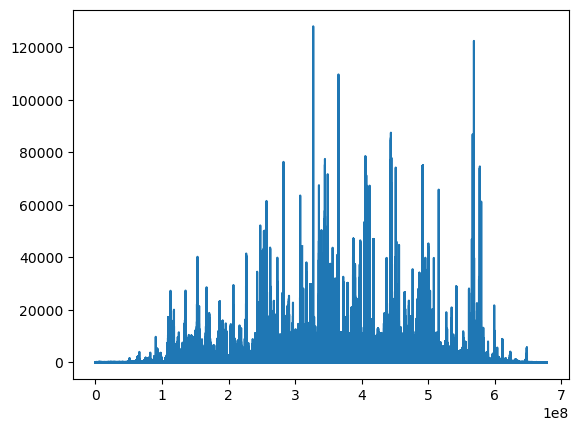

In [19]:
pop_df["pop"].plot()